This notebook was built to conduct some small preliminary screening phase on the first monk dataset. The goal was to get a sense of the hyperparameters impact, and to test the network.
Note that this version of the notebook does not contain the output plots, as they were removed to reduce the size of the delivery.
You can find the executed version [here](https://github.com/leonardocrociani/Neural-Network/blob/main/src/screening_monk.ipynb).

In [1]:
from lib.data_loader import get_monks_dataset
from lib.neural_network import NeuralNetwork
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm

X_dev, y_dev, X_test, y_test = get_monks_dataset(id=1, one_hot_encode=False)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_dev, y_dev, test_size=0.2, random_state=42
)

Using cached ../datasets/monks/monk-1-train.csv
Using cached ../datasets/monks/monk-1-test.csv


In [2]:
X_dev.shape

(124, 6)

5it [00:01,  3.77it/s]


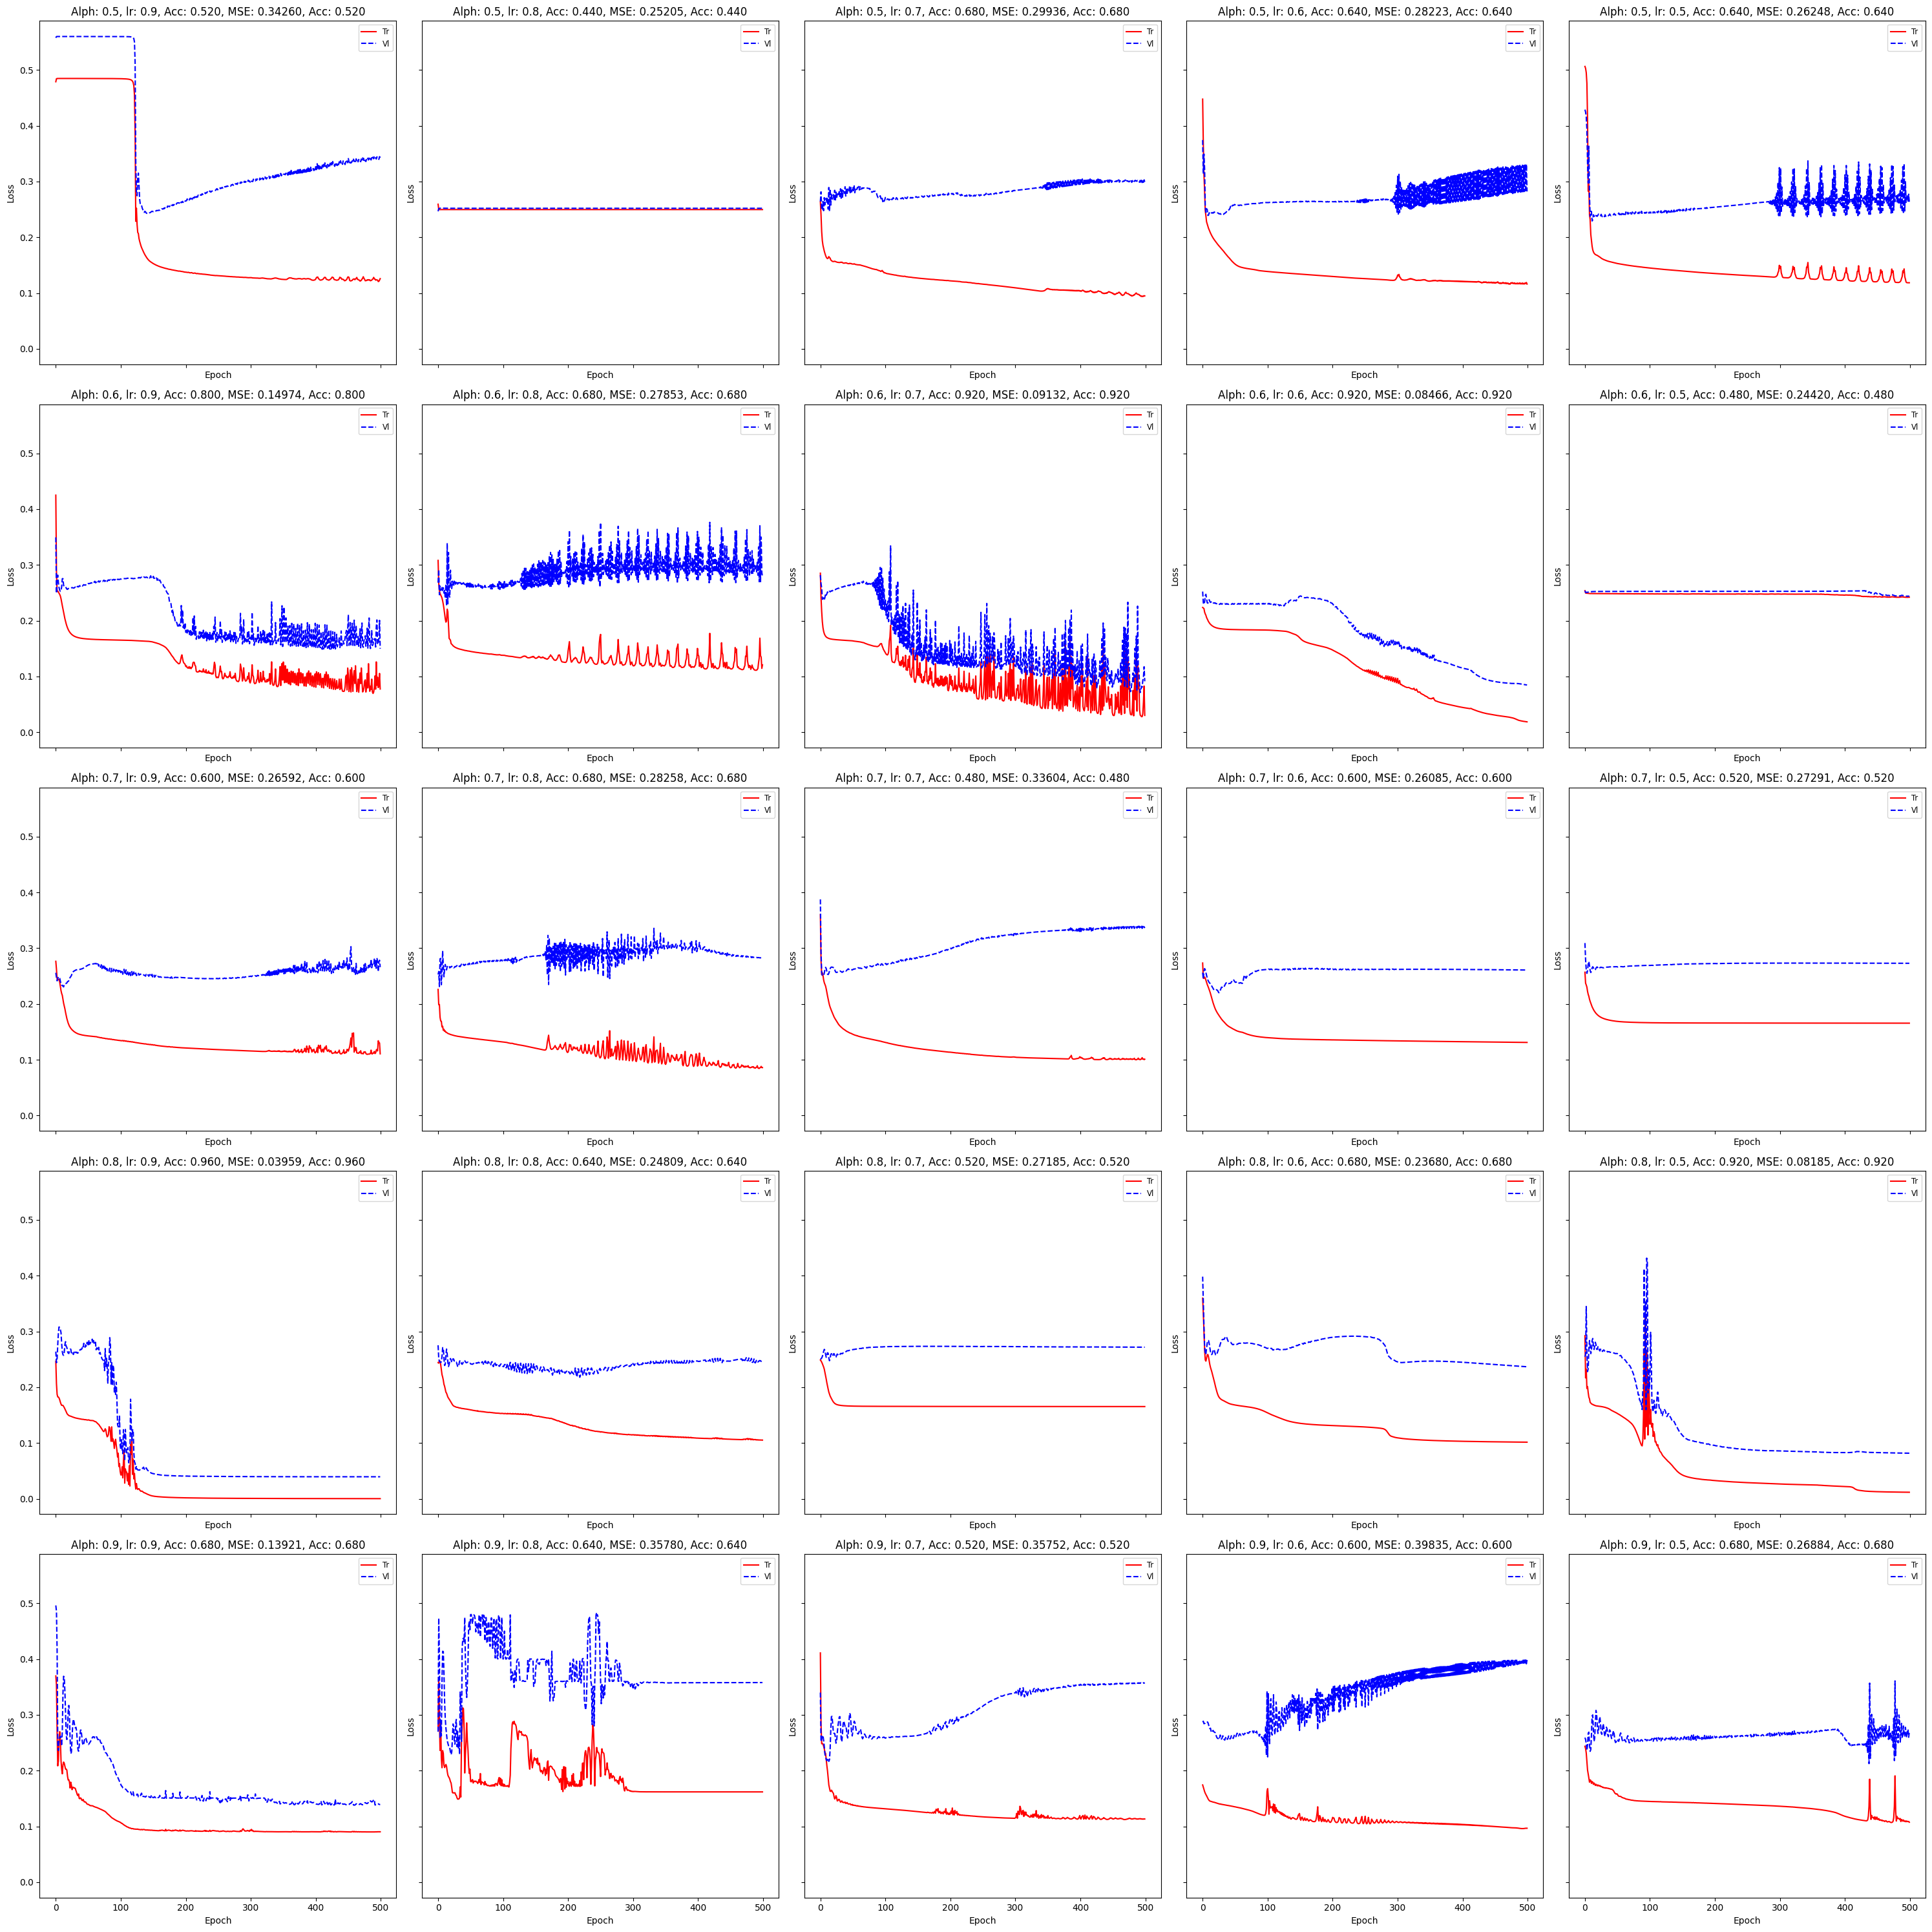

In [3]:
import numpy as np


alphas = [
    0.5, 0.6, 0.7, 0.8, 0.9
]

lrs = [
    0.9, 0.8, 0.7, 0.6, 0.5
]

fig, axs = plt.subplots(
    len(alphas),
    len(lrs),
    figsize=(len(lrs) * 6, len(alphas) * 6),
    sharex=True,
    sharey=True,
)

for i, alpha in tqdm(enumerate(alphas)):
    for j, lr in enumerate(lrs):
        nn = NeuralNetwork(
            layers=[X_train_split.shape[1], 4, 1],
            learning_rate=lr,
            lr_decay_type="none",
            error_function_name="mse",
            activation_function_names=["relu", "sigmoid"],
            reg_type="none",
            task="classification",
            weight_init="he",
            momentum_type="momentum",
            momentum_alpha=alpha,
        )

        nn.train(
            X_train_split,
            y_train_split,
            epochs=500,
            batch_size=X_train_split.shape[0],
            verbose=False,
            early_stopping=False,
            validation_data=(X_val_split, y_val_split),
        )

        ax = axs[i, j]
        ax.plot(nn.train_error_history, label=f"Tr", linestyle="-", color="red")
        ax.plot(nn.val_error_history, label=f"Vl", linestyle="--", color="blue")
        acc = nn.evaluate(X_val_split, y_val_split)
        mse = nn.evaluate(X_val_split, y_val_split, evaluation_function_name='mse', discretize=False)
        ax.set_title(f"Alph: {alpha}, lr: {lr}, Acc: {acc:.3f}, MSE: {mse :.5f}, Acc: {acc:.3f}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize="small")

plt.tight_layout()
plt.show()

In [4]:
from lib.data_loader import get_monks_dataset
from lib.neural_network import NeuralNetwork
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm

X_dev, y_dev, X_test, y_test = get_monks_dataset(id=1, one_hot_encode=True)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_dev, y_dev, test_size=0.2, random_state=42
)

Using cached ../datasets/monks/monk-1-train.csv
Using cached ../datasets/monks/monk-1-test.csv
One-hot encoding MONK-1 dataset...


5it [00:01,  3.72it/s]


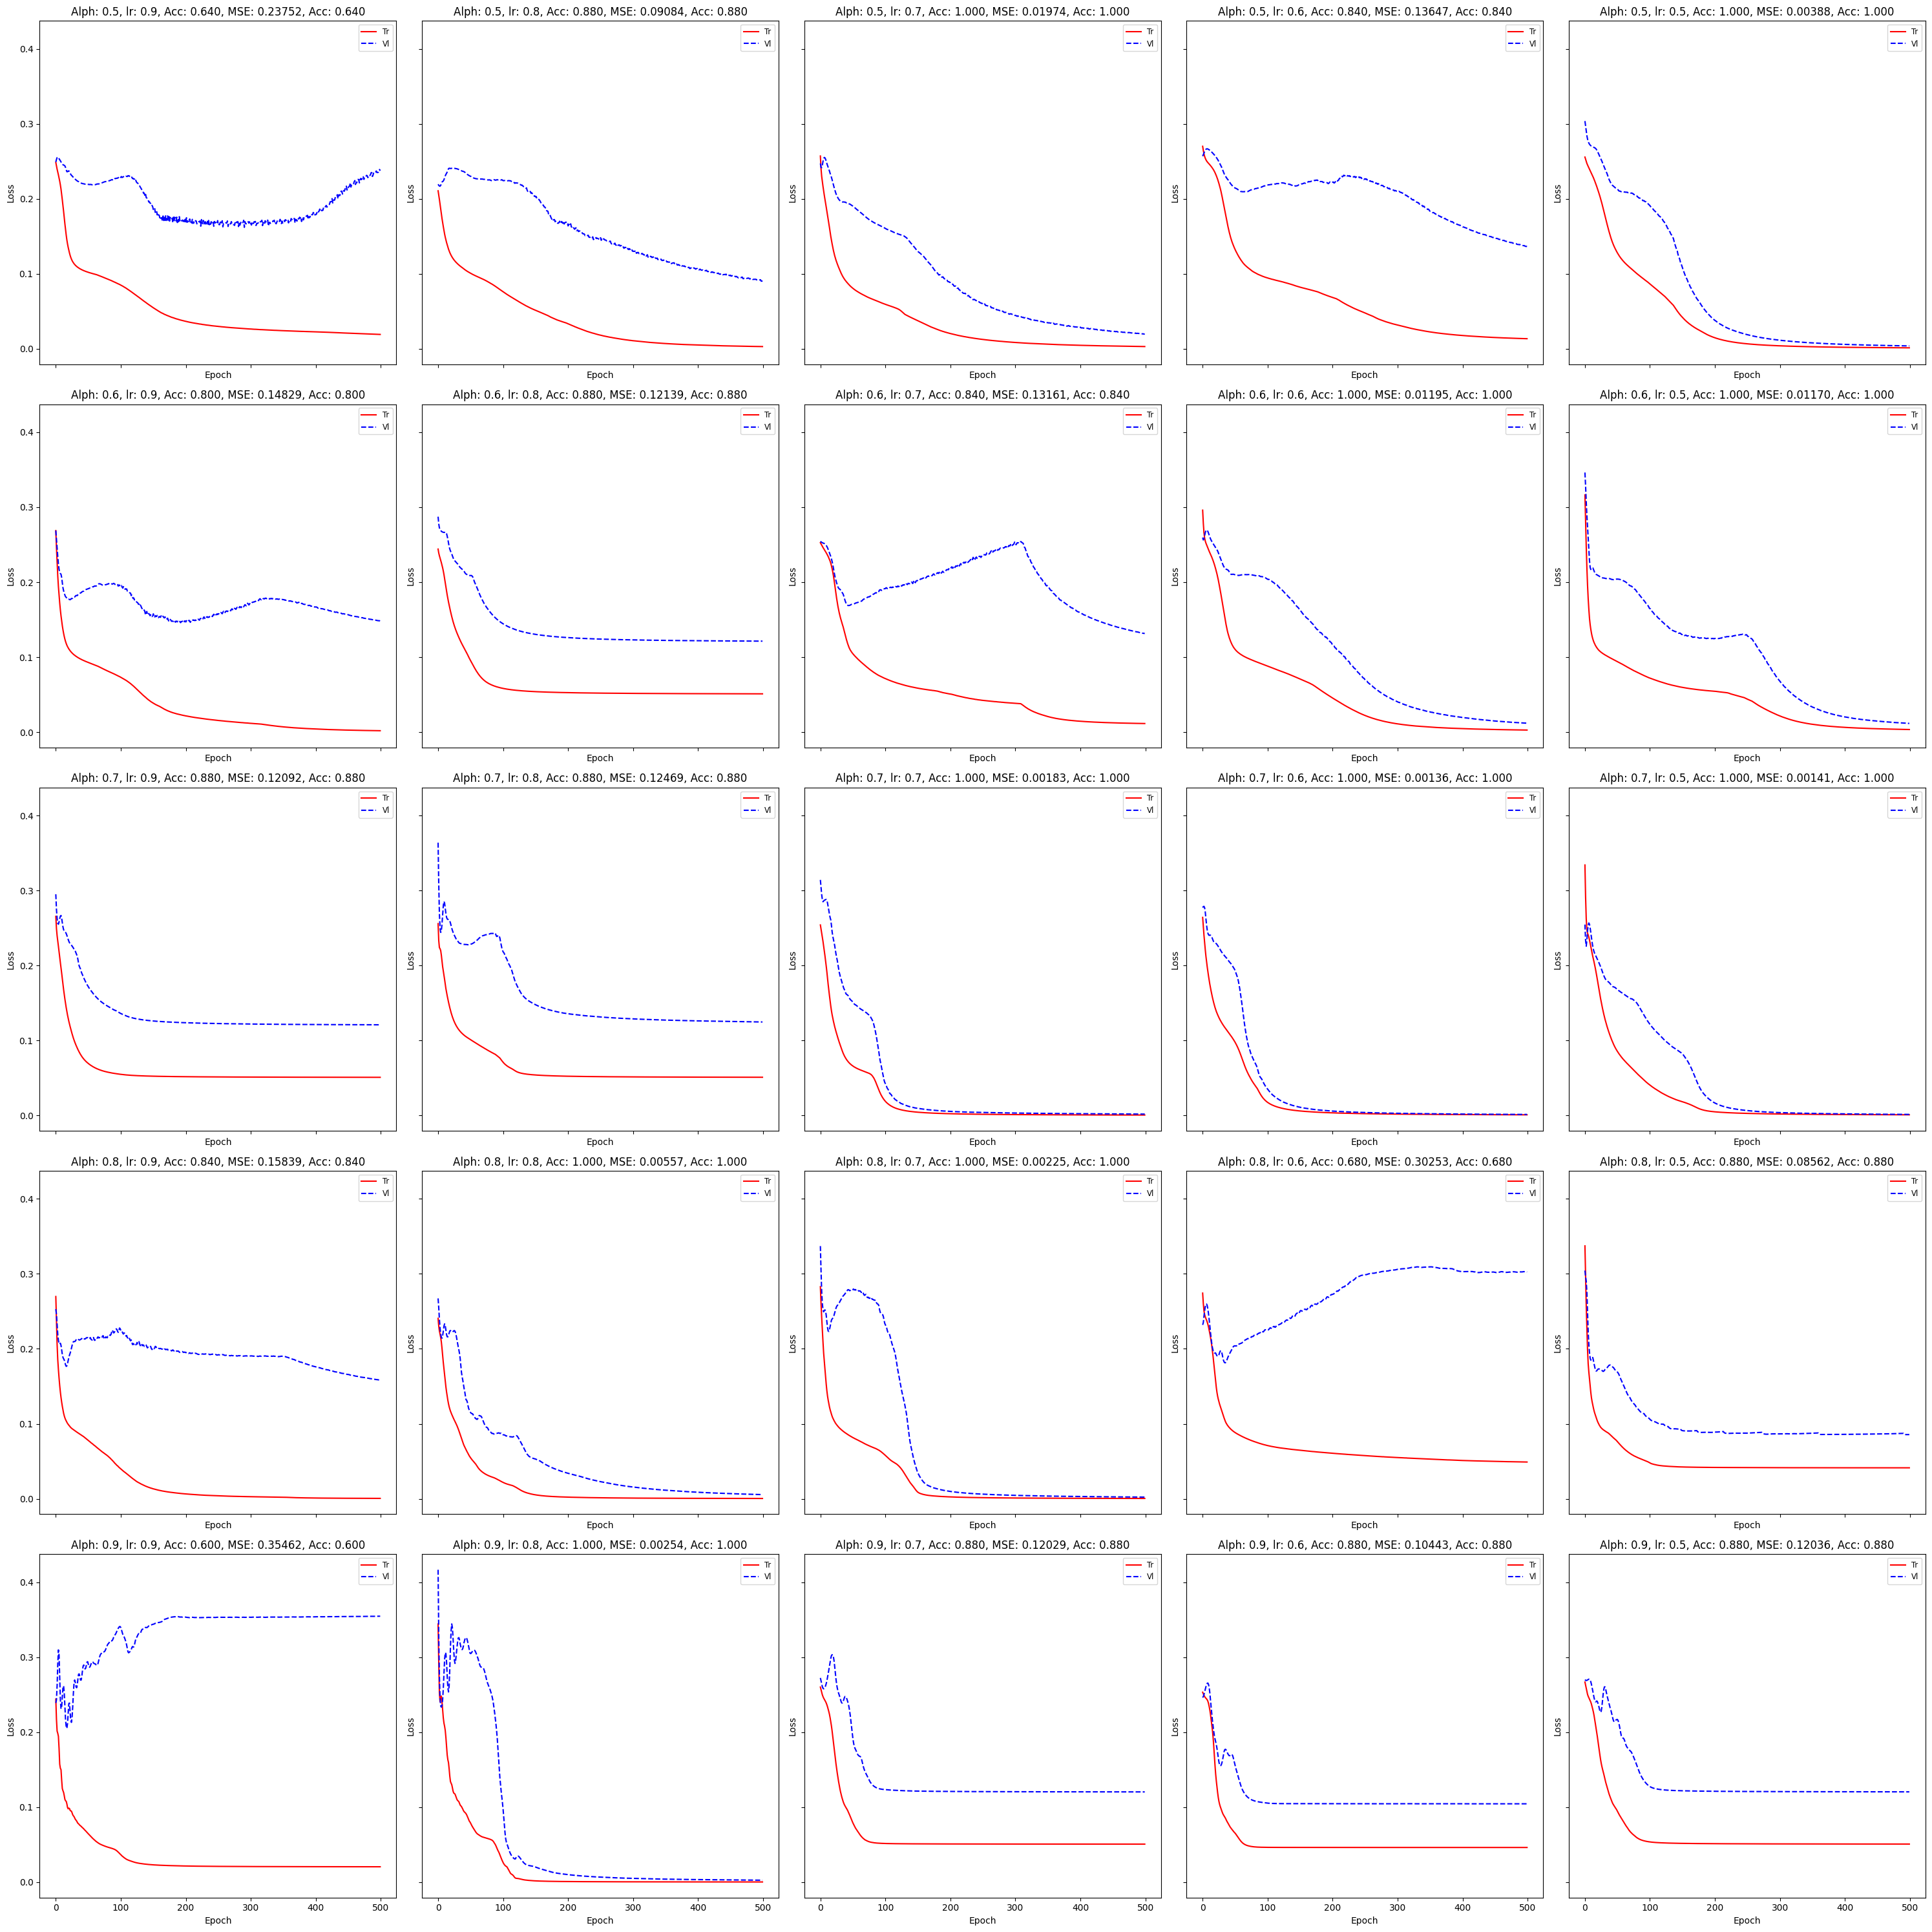

In [5]:
import numpy as np


alphas = [
    0.5, 0.6, 0.7, 0.8, 0.9
]

lrs = [
    0.9, 0.8, 0.7, 0.6, 0.5
]

fig, axs = plt.subplots(
    len(alphas),
    len(lrs),
    figsize=(len(lrs) * 6, len(alphas) * 6),
    sharex=True,
    sharey=True,
)

for i, alpha in tqdm(enumerate(alphas)):
    for j, lr in enumerate(lrs):
        nn = NeuralNetwork(
            layers=[X_train_split.shape[1], 4, 1],
            learning_rate=lr,
            lr_decay_type="none",
            error_function_name="mse",
            activation_function_names=["relu", "sigmoid"],
            reg_type="none",
            task="classification",
            weight_init="he",
            momentum_type="momentum",
            momentum_alpha=alpha,
        )

        nn.train(
            X_train_split,
            y_train_split,
            epochs=500,
            batch_size=X_train_split.shape[0],
            verbose=False,
            early_stopping=False,
            validation_data=(X_val_split, y_val_split),
        )

        ax = axs[i, j]
        ax.plot(nn.train_error_history, label=f"Tr", linestyle="-", color="red")
        ax.plot(nn.val_error_history, label=f"Vl", linestyle="--", color="blue")
        acc = nn.evaluate(X_val_split, y_val_split)
        mse = nn.evaluate(X_val_split, y_val_split, evaluation_function_name='mse', discretize=False)
        ax.set_title(f"Alph: {alpha}, lr: {lr}, Acc: {acc:.3f}, MSE: {mse :.5f}, Acc: {acc:.3f}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize="small")

plt.tight_layout()
plt.show()

# One hot encoding definitivly help

In [6]:
import numpy as np


SIMULATIONS = 10
RESULTS = {}

alphas = [
   0.77, 0.78, 0.79, 0.8, 0.81, 0.82, 0.83, 0.84, 0.85
]

lrs = [
    0.3, 0.25, 0.2, 0.15, 0.1, 0.05, 0.01, 0.005, 0.001
]

from tqdm import tqdm

for _ in tqdm(range(SIMULATIONS)):
    for i, alpha in tqdm(enumerate(alphas)):
        for j, lr in enumerate(lrs):
            
            key = (alpha, lr)
            if key not in RESULTS:
                RESULTS[key] = []
            
            nn = NeuralNetwork(
                layers=[17, 4, 1],
                learning_rate=lr,
                lr_decay_type="none",
                error_function_name="mse",
                activation_function_names=["relu", "sigmoid"],
                reg_type="none",
                task="classification",
                weight_init="he",
                momentum_type="momentum",
                momentum_alpha=alpha,
            )

            nn.train(
                X_train_split,
                y_train_split,
                epochs=100,
                batch_size=1,
                verbose=False,
                early_stopping=False,
                validation_data=(X_val_split, y_val_split),
            )

            RESULTS[key].append(
                {
                    'error' : nn.val_error_history[-1],
                    'acc' : nn.evaluate(X_val_split, y_val_split)
                }
            )




9it [00:22,  2.50s/it][00:00<?, ?it/s]
9it [00:22,  2.54s/it][00:22<03:23, 22.56s/it]
9it [00:21,  2.41s/it][00:45<03:01, 22.72s/it]
9it [00:21,  2.37s/it][01:07<02:35, 22.25s/it]
9it [00:21,  2.43s/it][01:28<02:11, 21.89s/it]
9it [00:22,  2.47s/it][01:50<01:49, 21.91s/it]
9it [00:21,  2.44s/it][02:12<01:28, 22.01s/it]
9it [00:21,  2.42s/it][02:34<01:05, 21.99s/it]
9it [00:21,  2.41s/it][02:56<00:43, 21.93s/it]
9it [00:21,  2.41s/it][03:17<00:21, 21.85s/it]
100%|██████████| 10/10 [03:39<00:00, 21.97s/it]


In [7]:
# find the one with less stddev and lower error
best_alpha = None
best_lr = None
best_error = float('inf')
best_acc = 0
best_std = 0

for key, values in RESULTS.items():
    errors = [v['error'] for v in values]
    accs = [v['acc'] for v in values]
    mean_error = np.mean(errors)
    mean_acc = np.mean(accs)
    std_error = np.std(errors)
    if mean_error < best_error:
        best_alpha, best_lr = key
        best_error = mean_error
        best_acc = mean_acc
        best_std = std_error
        
print(f"Best Alpha: {best_alpha}, Best lr: {best_lr}, Best Error: {best_error}, Best Acc: {best_acc}, STD: {std_error}")

Best Alpha: 0.8, Best lr: 0.05, Best Error: 0.018903304950459963, Best Acc: 0.9800000000000001, STD: 0.03577233146286255


1.0


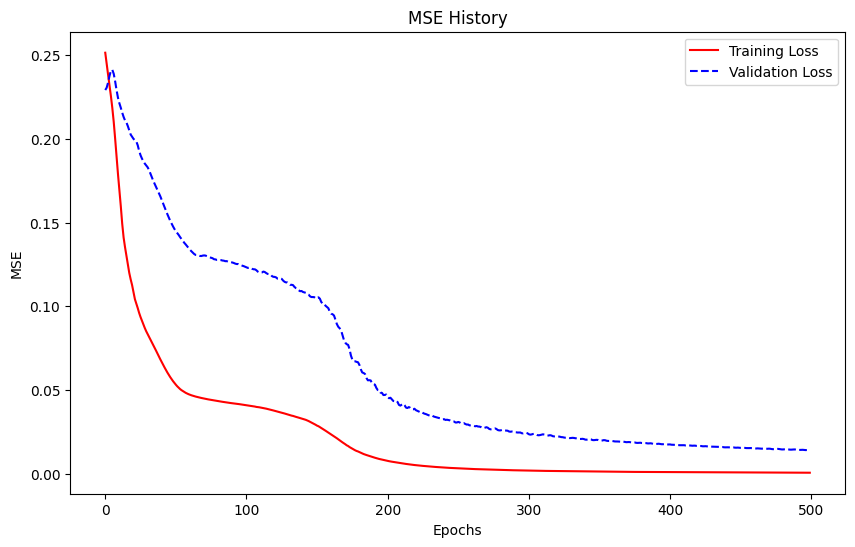

In [8]:
nn = NeuralNetwork(
    layers=[17, 4, 1],
    learning_rate=0.8,
    lr_decay_type="none",
    error_function_name="mse",
    activation_function_names=["relu", "sigmoid"],
    reg_type="none",
    task="classification",
    weight_init="he",
    momentum_type="momentum",
    momentum_alpha=0.8,
)
nn.train(
    X_train_split,
    y_train_split,
    epochs=500,
    batch_size=X_train_split.shape[0],
    verbose=False,
    early_stopping=False,
    validation_data=(X_val_split, y_val_split),
)
nn.plot_learning_curve()
print(nn.evaluate(X_val_split, y_val_split))

5it [00:04,  1.14it/s]


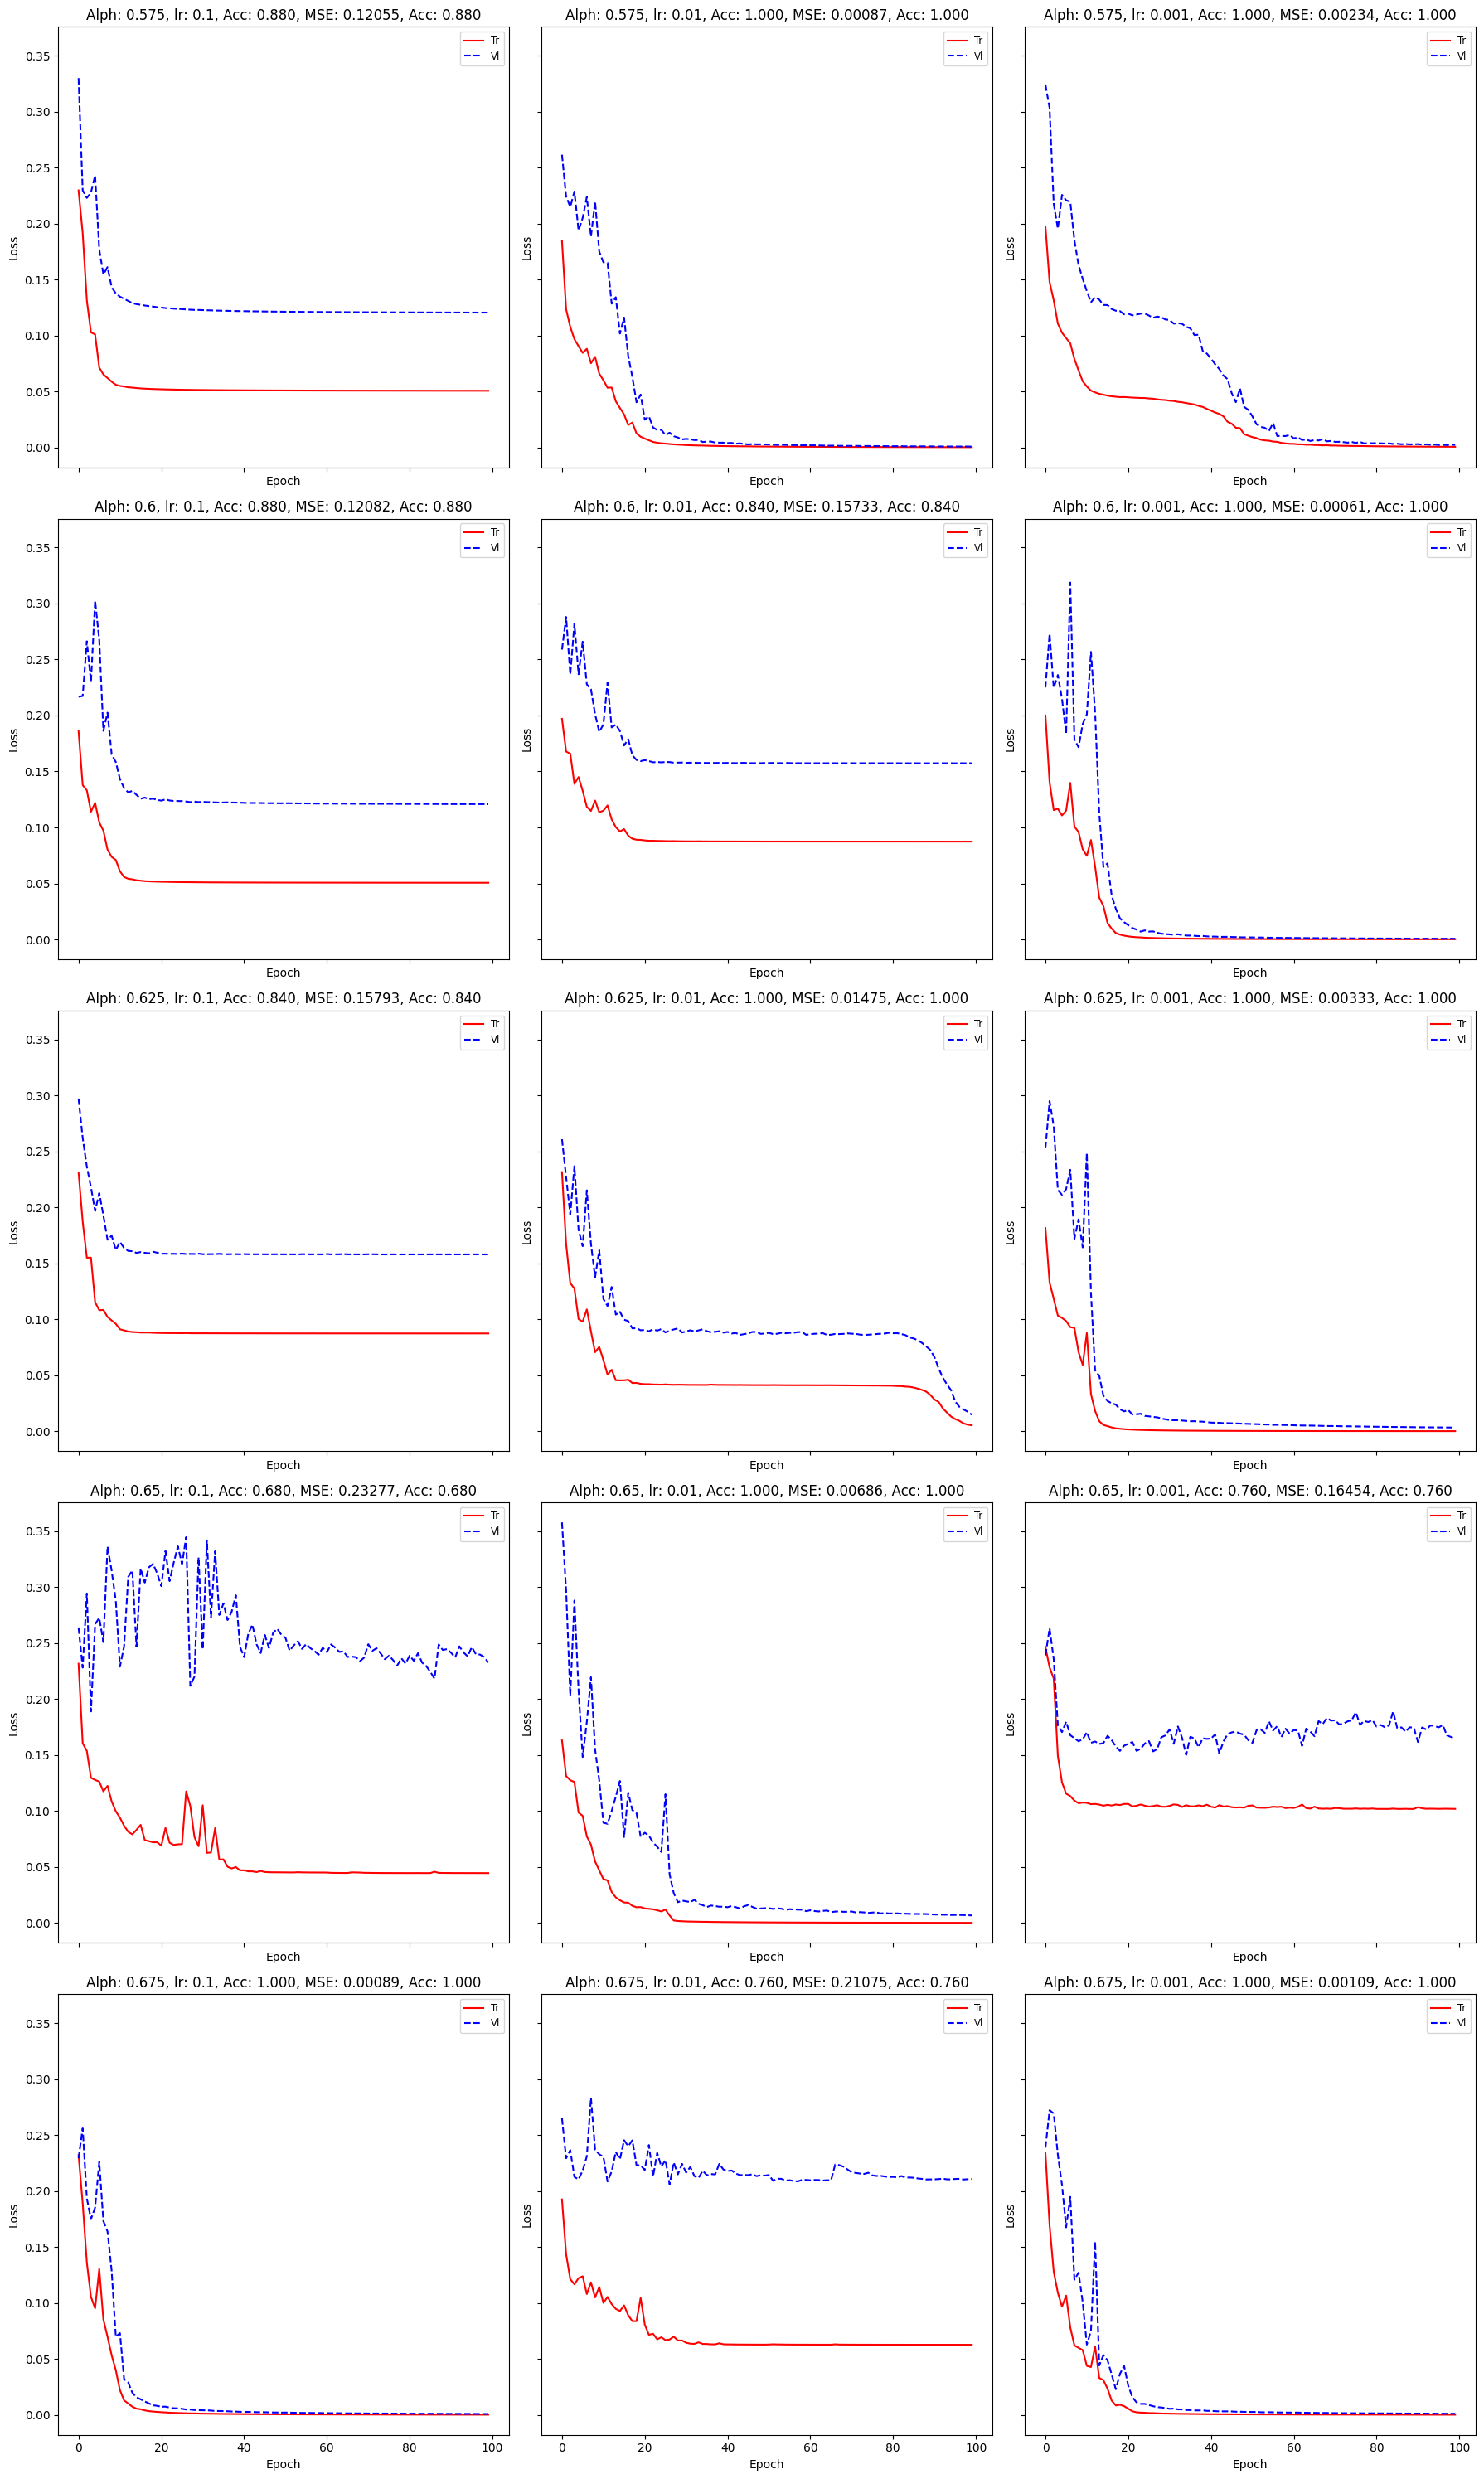

In [9]:
import numpy as np


alphas = [
    0.575, 0.6, 0.625, 0.65, 0.675
]

lrs = [0.1, 0.01, 0.001]

fig, axs = plt.subplots(
    len(alphas),
    len(lrs),
    figsize=(len(lrs) * 6, len(alphas) * 6),
    sharex=True,
    sharey=True,
)

for i, alpha in tqdm(enumerate(alphas)):
    for j, lr in enumerate(lrs):
        nn = NeuralNetwork(
            layers=[17, 4, 1],
            learning_rate=0.1,
            lr_decay_type="none",
            error_function_name="mse",
            activation_function_names=["relu", "sigmoid"],
            reg_type="none",
            task="classification",
            weight_init="he",
            momentum_type="momentum",
            momentum_alpha=alpha,
        )

        nn.train(
            X_train_split,
            y_train_split,
            epochs=100,
            batch_size=1,
            verbose=False,
            early_stopping=False,
            validation_data=(X_val_split, y_val_split),
        )

        ax = axs[i, j]
        ax.plot(nn.train_error_history, label=f"Tr", linestyle="-", color="red")
        ax.plot(nn.val_error_history, label=f"Vl", linestyle="--", color="blue")
        acc = nn.evaluate(X_val_split, y_val_split)
        mse = nn.evaluate(X_val_split, y_val_split, evaluation_function_name='mse', discretize=False)
        ax.set_title(f"Alph: {alpha}, lr: {lr}, Acc: {acc:.3f}, MSE: {mse :.5f}, Acc: {acc:.3f}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend(fontsize="small")

plt.tight_layout()
plt.show()